In [185]:
library(ade4)
library(ggbiplot)

library(tidyverse)
library(colorRamps)
library(wesanderson)
library(plotly)
library(stringr)
library(broom)
library(patchwork)
library(dplyr)

options(repr.plot.width=12, repr.plot.heigh=12)

In [186]:
my_palette <- wes_palette("FantasticFox1", 12, type = "continuous")

# Set default color and fill scales globally
update_geom_defaults("bar", list(fill = my_palette[1], color= "white"))
update_geom_defaults("col", list(fill = my_palette[2], color="white"))

scale_fill_discrete <- function(...) scale_fill_manual(values = my_palette, ...)
scale_color_discrete <- function(...) scale_color_manual(values = my_palette, ...)

In [187]:
ThemeMain<-theme( title =element_text(size=16, face='bold'),
                 axis.text.y = element_blank(), 
                 axis.text.x = element_text(color='black'),
                 axis.ticks.y = element_blank(),
                 axis.title.x = element_text(size=16,color='black',face='bold')
                 )


theme_set(theme_bw())
theme_set(ThemeMain)

In [188]:
df <- read.csv("../data/owid-energy-data.csv") %>%
    filter(year == 2010)

In [189]:
head(df, 5)

,country,year,iso_code,population,gdp,biofuel_cons_change_pct,biofuel_cons_change_twh,biofuel_cons_per_capita,biofuel_consumption,biofuel_elec_per_capita,⋯,solar_share_elec,solar_share_energy,wind_cons_change_pct,wind_cons_change_twh,wind_consumption,wind_elec_per_capita,wind_electricity,wind_energy_per_capita,wind_share_elec,wind_share_energy
,<chr>,<int>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,ASEAN (Ember),2010,,NA,NA,NA,NA,NA,NA,NA,⋯,0.010,NA,NA,NA,NA,NA,0.100,NA,0.015,NA
2,Afghanistan,2010,AFG,28189672,47399424000,NA,NA,NA,NA,0.000,⋯,0.000,NA,NA,NA,NA,0.000,0.000,NA,0.000,NA
3,Africa,2010,,1055233717,NA,-38.165,-0.13,0.2,0.211,2.843,⋯,0.033,0.013,43.734,1.902,6.341,2.161,2.280,6.01,0.339,0.142
4,Africa (EI),2010,,NA,NA,-38.165,-0.13,NA,0.211,NA,⋯,0.030,0.013,43.734,1.902,6.341,NA,2.285,NA,0.340,0.142
5,Africa (EIA),2010,,NA,NA,NA,NA,NA,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA


In [190]:
SUBSET = c("biofuel_elec_per_capita", "coal_elec_per_capita", "fossil_elec_per_capita", "gas_elec_per_capita", "hydro_elec_per_capita", "low_carbon_elec_per_capita", "nuclear_elec_per_capita", "oil_elec_per_capita",  "solar_elec_per_capita", "wind_elec_per_capita", "low_carbon_elec_per_capita", "renewables_elec_per_capita", "other_renewables_elec_per_capita", "gdp")

In [191]:
df_sub = df[,SUBSET] %>% drop_na()

In [192]:
for ( col in 1:ncol(df_sub)){
    colnames(df_sub)[col] <-  sub("_elec_per_capita.*", "", colnames(df_sub)[col])
}

In [194]:
pca = prcomp(df_sub, scale. = TRUE)

In [209]:
library(viridis)

Loading required package: viridisLite


Attaching package: ‘viridis’


The following object is masked from ‘package:scales’:

    viridis_pal




Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_point()`).”


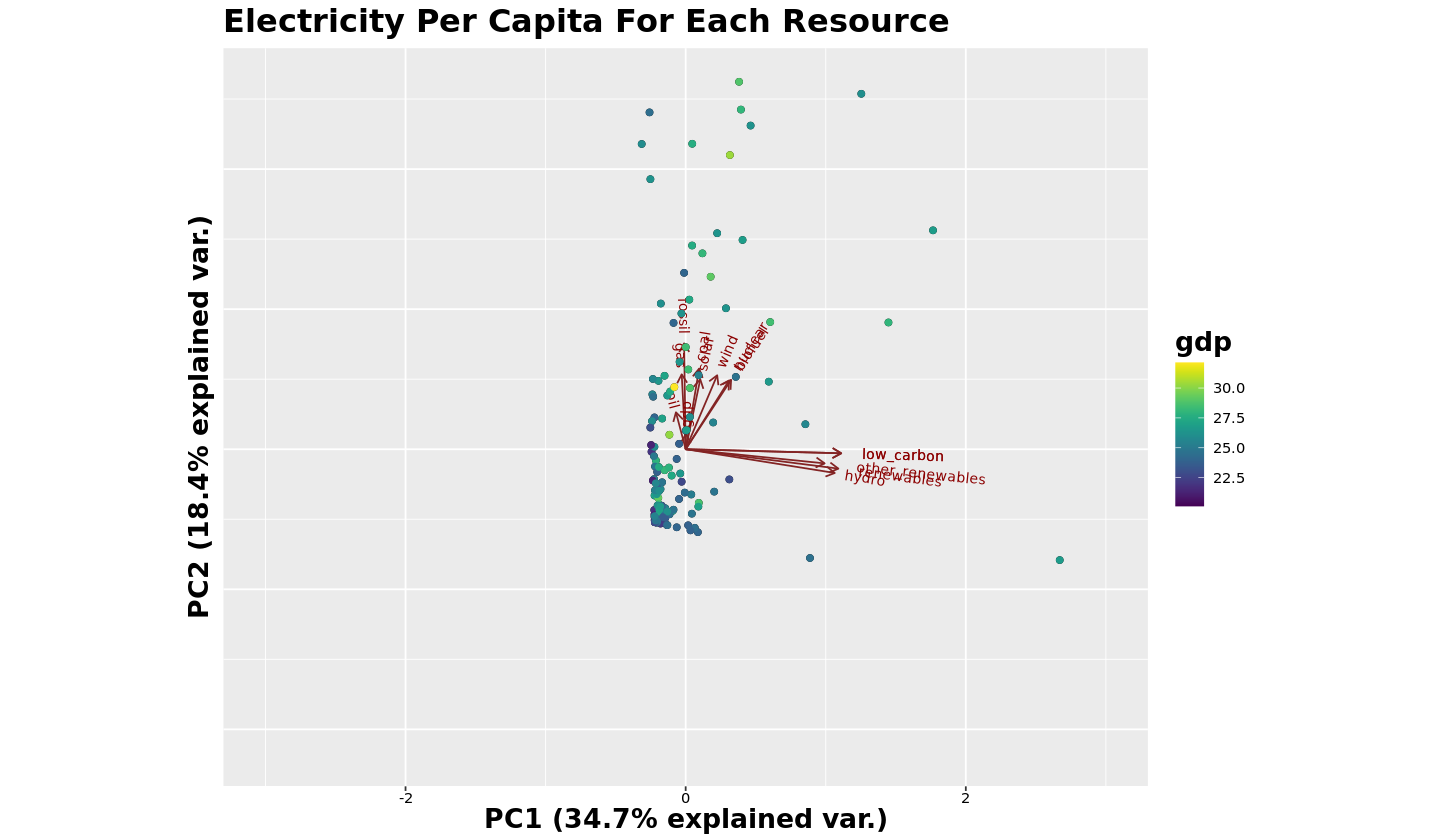

In [210]:


ggbiplot(pca, scale = 1.5) + xlim(c(-3, 3)) +
    geom_point(aes(color = log(df_sub$gdp))) + 
    labs(title="Electricity Per Capita For Each Resource") +
    scale_color_viridis("gdp")

### Observations

Through covariance principle component analysis I am aiming to find the similarity between the different resources electricty per capita. I project all the columns on the two highest principle components and plot each of the points. Additionaly, Each of the colors are colored based on the gdp of the country. Within this plot we observe two major patterns the first is the relationship between some of the energy columns renewables, There are two major groupings of axis which likely have large cosine values amongst the groupings. one contains hydro, low carbon,and renewables. Interestingly not all of the renewable resources are amongst the first group the second group contains fossil, wind, gas, oil. , The second interesting observation is the location of points for countries, we observe that low gdp countries have negative values for most axis.